##PIZZA SALES ANALYSIS

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import plotly.express as px

##Import Raw Data

In [68]:
df=pd.read_csv("/content/sample_data/pizza_sales (1).csv")

In [69]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [70]:
df.tail()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31-12-2015,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [71]:
print("The no of rows and Columns in this dataset: ",df.shape)

The no of rows and Columns in this dataset:  (48620, 12)


In [72]:
df.shape[0]

48620

In [73]:
df.shape[1]

12

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [75]:
df.info

<bound method DataFrame.info of        pizza_id  order_id  pizza_name_id  quantity  order_date order_time  \
0             1         1     hawaiian_m         1  01-01-2015   11:38:36   
1             2         2  classic_dlx_m         1  01-01-2015   11:57:40   
2             3         2  five_cheese_l         1  01-01-2015   11:57:40   
3             4         2    ital_supr_l         1  01-01-2015   11:57:40   
4             5         2     mexicana_m         1  01-01-2015   11:57:40   
...         ...       ...            ...       ...         ...        ...   
48615     48616     21348  ckn_alfredo_m         1  31-12-2015   21:23:10   
48616     48617     21348  four_cheese_l         1  31-12-2015   21:23:10   
48617     48618     21348   napolitana_s         1  31-12-2015   21:23:10   
48618     48619     21349     mexicana_l         1  31-12-2015   22:09:54   
48619     48620     21350      bbq_ckn_s         1  31-12-2015   23:02:05   

       unit_price  total_price pizza_size pizza_category  \
0           13.25        13.25          M        Classic   
1           16.00        16.00          M        Classic   
2           18.50        18.50          L         Veggie   
3           20.75        20.75          L        Supreme   
4           16.00        16.00          M         Veggie   
...           ...          ...        ...            ...   
48615       16.75        16.75          M        Chicken   
48616       17.95        17.95          L         Veggie   
48617       12.00        12.00          S        Classic   
48618       20.25        20.25          L         Veggie   
48619       12.75        12.75          S        Chicken   

                                       pizza_ingredients  \
0               Sliced Ham, Pineapple, Mozzarella Cheese   
1      Pepperoni, Mushrooms, Red Onions, Red Peppers,...   
2      Mozzarella Cheese, Provolone Cheese, Smoked Go...   
3      Calabrese Salami, Capocollo, Tomatoes, Red Oni...   
4      Tomatoes, Red Peppers, Jalapeno Peppers, Red O...   
...                                                  ...   
48615  Chicken, Red Onions, Red Peppers, Mushrooms, A...   
48616  Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...   
48617  Tomatoes, Anchovies, Green Olives, Red Onions,...   
48618  Tomatoes, Red Peppers, Jalapeno Peppers, Red O...   
48619  Barbecued Chicken, Red Peppers, Green Peppers,...   

                       pizza_name  
0              The Hawaiian Pizza  
1        The Classic Deluxe Pizza  
2           The Five Cheese Pizza  
3       The Italian Supreme Pizza  
4              The Mexicana Pizza  
...                           ...  
48615   The Chicken Alfredo Pizza  
48616       The Four Cheese Pizza  
48617        The Napolitana Pizza  
48618          The Mexicana Pizza  
48619  The Barbecue Chicken Pizza  

[48620 rows x 12 columns]>

In [76]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [77]:
#Datatypes
df.dtypes

,0
pizza_id,int64
order_id,int64
pizza_name_id,object
quantity,int64
order_date,object
order_time,object
unit_price,float64
total_price,float64
pizza_size,object
pizza_category,object


In [78]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


##Key Findings---KPI

In [79]:
total_revenue=df['total_price'].sum()
total_pizza_sold=df['quantity'].sum()
total_orders=df['order_id'].nunique()
Avg_order_per_value=total_revenue/total_orders
Avg_Pizza_per_order=total_pizza_sold/total_orders

In [80]:
print(f"Total_Revenue : ${total_revenue:,.2f}")
print(f"Total pizza Sold: {total_pizza_sold:}")
print(f"Total Orders: {total_orders:}")
print(f"Avg Order Per Value: ${Avg_order_per_value:,.2f}")
print(f"Avg pizza per Order: {Avg_Pizza_per_order:.2f}")

Total_Revenue : $817,860.05
Total pizza Sold: 49574
Total Orders: 21350
Avg Order Per Value: $38.31
Avg pizza per Order: 2.32


##Charts---Ingredients Analysis

In [81]:
Ingredients=(

             df['pizza_ingredients']
             .str.split(',')
             .explode()
             .str.strip()
             .value_counts()
             .reset_index()
             .rename(columns = {'index':"Count" ,'pizza_ingredients':"Ingredients"})

)

In [82]:
#Top 15 main Ingredients
print(Ingredients.head(15))

          Ingredients  count
0              Garlic  27422
1            Tomatoes  26601
2          Red Onions  19547
3         Red Peppers  16284
4   Mozzarella Cheese  10333
5           Pepperoni  10300
6             Spinach  10012
7           Mushrooms   9624
8             Chicken   8443
9           Capocollo   6572
10       Green Olives   6174
11         Artichokes   5682
12   Jalapeno Peppers   5643
13      Green Peppers   5224
14        Feta Cheese   4748


In [83]:
#Bottom 5 less Ingredients
print(Ingredients.tail(5))

           Ingredients  count
60   Brie Carre Cheese    480
61          Prosciutto    480
62  Caramelized Onions    480
63               Pears    480
64               Thyme    480


#Daily trend for Total Orders

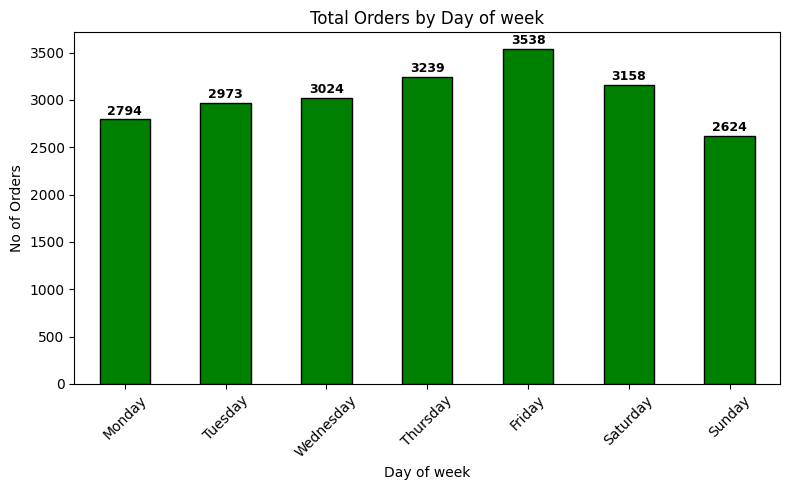

In [84]:
df['order_date']=pd.to_datetime(df['order_date'],dayfirst=True)
df['day_name']=df['order_date'].dt.day_name()
weekday_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df['day_name']=pd.Categorical(df['day_name'],categories=weekday_order,ordered=True)
orders_by_day=df.groupby('day_name',observed=False)['order_id'].nunique()
ax=orders_by_day.plot(kind='bar',figsize=(8,5),color='green',edgecolor='black')


plt.title("Total Orders by Day of week")
plt.xlabel("Day of week")
plt.ylabel("No of Orders")
plt.xticks(rotation=45)

for i,val in enumerate(orders_by_day):
  plt.text(i,val+20,str(val),ha='center',va='bottom',fontsize=9,fontweight='bold')


plt.tight_layout()
plt.show()


#Daily trend for Total Revenue

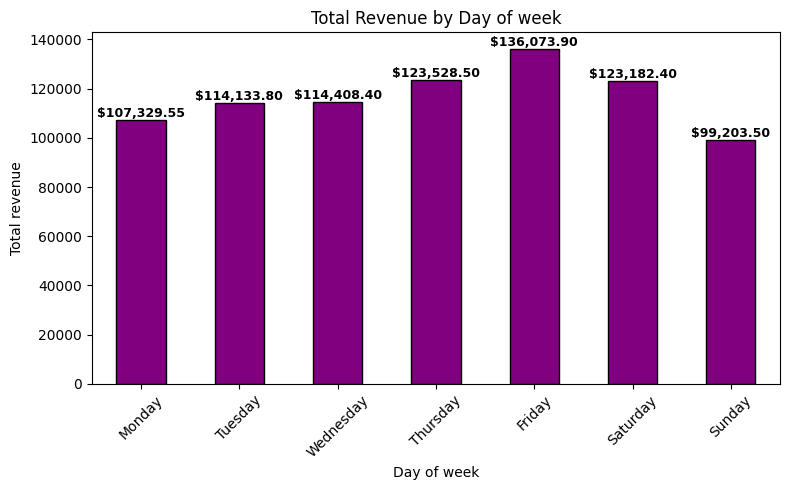

In [94]:
df['order_date']=pd.to_datetime(df['order_date'],dayfirst=True)
df['day_name']=df['order_date'].dt.day_name()
weekday_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df['day_name']=pd.Categorical(df['day_name'],categories=weekday_order,ordered=True)
orders_by_day=df.groupby('day_name',observed=False)['total_price'].sum()
ax=orders_by_day.plot(kind='bar',figsize=(8,5),color='purple',edgecolor='black')


plt.title("Total Revenue by Day of week")
plt.xlabel("Day of week")
plt.ylabel("Total revenue")
plt.xticks(rotation=45)

for i,val in enumerate(orders_by_day):
  formatted = f"${val:,.2f}"    # Add $ and two decimals

  plt.text(i, val + 20, formatted, ha='center', va='bottom',
             fontsize=9, fontweight='bold')



plt.tight_layout()
plt.show()


#Hourly trend for Total Orders

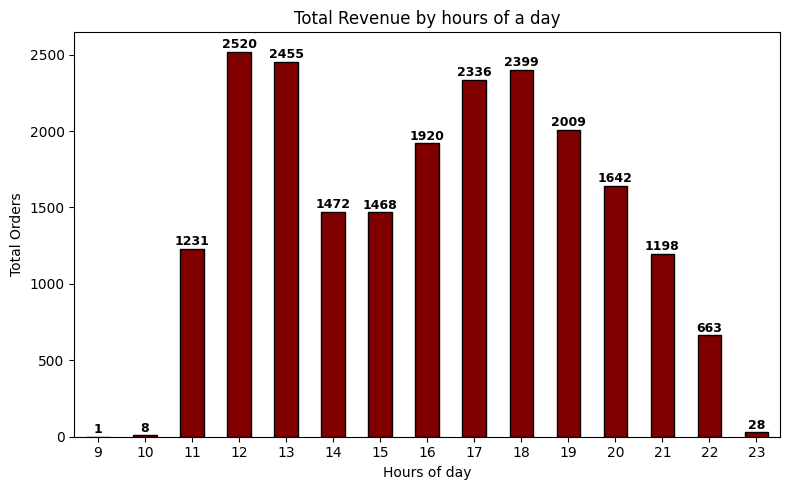

In [96]:
df['order_time']=pd.to_datetime(df['order_time'],format='%H:%M:%S')
df['order_hour']=df['order_time'].dt.hour
orders_by_hour=df.groupby('order_hour',observed=False)['order_id'].nunique()
ax=orders_by_hour.plot(kind='bar',figsize=(8,5),color='maroon',edgecolor='black')


plt.title("Total Orders by hours of a day")
plt.xlabel("Hours of day")
plt.ylabel("Total Orders")
plt.xticks(rotation=0)

for i,val in enumerate(orders_by_hour):
  plt.text(i, val + 5, str(val), ha='center', va='bottom',
             fontsize=9, fontweight='bold')



plt.tight_layout()
plt.show()


#Hourly trend for Total Revenue

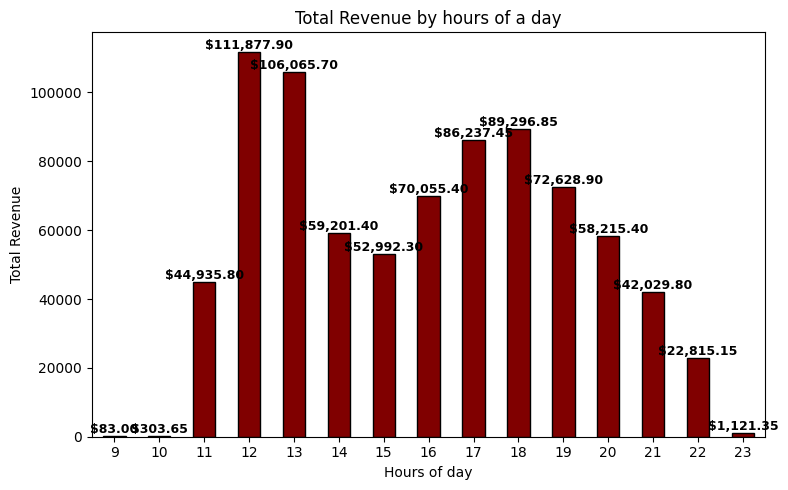

In [99]:
df['order_time']=pd.to_datetime(df['order_time'],format='%H:%M:%S')
df['order_hour']=df['order_time'].dt.hour
orders_by_hour=df.groupby('order_hour',observed=False)['total_price'].sum()
ax=orders_by_hour.plot(kind='bar',figsize=(8,5),color='maroon',edgecolor='black')


plt.title("Total Revenue by hours of a day")
plt.xlabel("Hours of day")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

for i,val in enumerate(orders_by_hour):
  formatted = f"${val:,.2f}"
  plt.text(i, val + 5,formatted, ha='center', va='bottom',
             fontsize=9, fontweight='bold')



plt.tight_layout()
plt.show()

#Monthly Trend for Total Orders

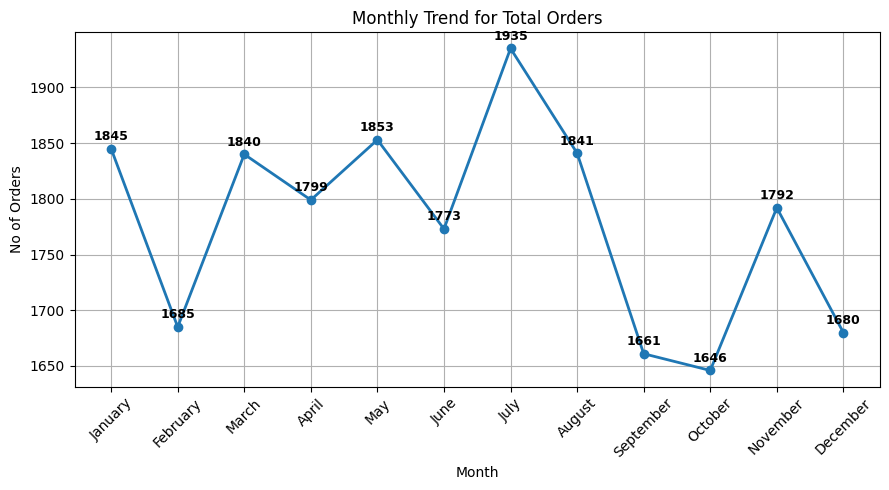

In [102]:
# Convert order_date to datetime (if not already done)
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Extract month name
df['month_name'] = df['order_date'].dt.month_name()

# Ordered month list
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

df['month_name'] = pd.Categorical(df['month_name'],
                                  categories=month_order,
                                  ordered=True)

# Group by month and count unique orders
orders_by_month = df.groupby('month_name', observed=False)['order_id'].nunique()

# Line chart
plt.figure(figsize=(9,5))
plt.plot(orders_by_month.index, orders_by_month.values, marker='o', linewidth=2)

plt.title("Monthly Trend for Total Orders")
plt.xlabel("Month")
plt.ylabel("No of Orders")
plt.xticks(rotation=45)
plt.grid(True)

# Add labels to each point
for i, val in enumerate(orders_by_month):
    plt.text(i, val + 5, str(val), ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


#Monthly Trend for Total Revenue

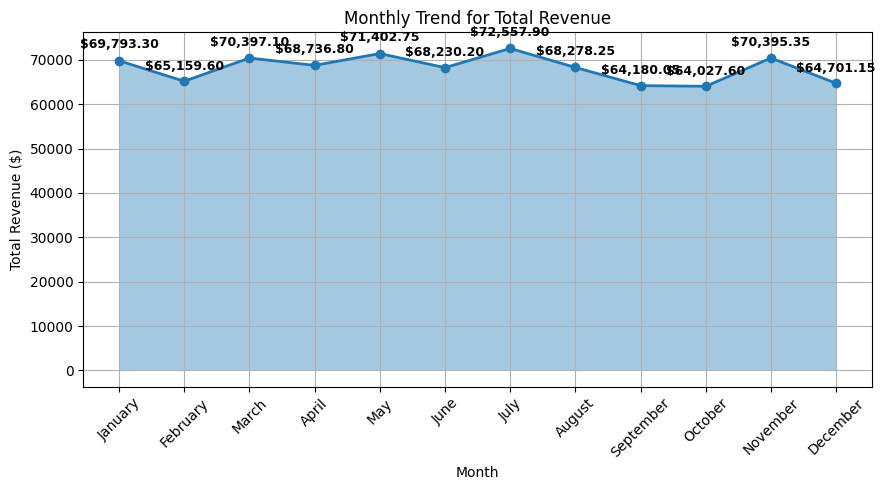

In [107]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Extract month name
df['month_name'] = df['order_date'].dt.month_name()

# Ordered month list
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

df['month_name'] = pd.Categorical(df['month_name'],
                                  categories=month_order,
                                  ordered=True)

# Group by month and calculate total revenue
revenue_by_month = df.groupby('month_name', observed=False)['total_price'].sum()

# Area chart
plt.figure(figsize=(9,5))
plt.fill_between(revenue_by_month.index, revenue_by_month.values, alpha=0.4)
plt.plot(revenue_by_month.index, revenue_by_month.values, marker='o', linewidth=2)

plt.title("Monthly Trend for Total Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.grid(True)

# Add labels with $ and 2 decimal values
for i, val in enumerate(revenue_by_month):
    formatted = f"${val:,.2f}"
    plt.text(i, val + (val * 0.03), formatted, ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [114]:
# Calculate revenue per category
category_revenue = df.groupby('pizza_category')['total_price'].sum()

# Calculate % share
category_percent = (category_revenue / category_revenue.sum()) * 100

# Format to 2 decimals
category_percent = category_percent.round(2)

category_percent



,total_price
pizza_category,
Chicken,23.96
Classic,26.91
Supreme,25.46
Veggie,23.68


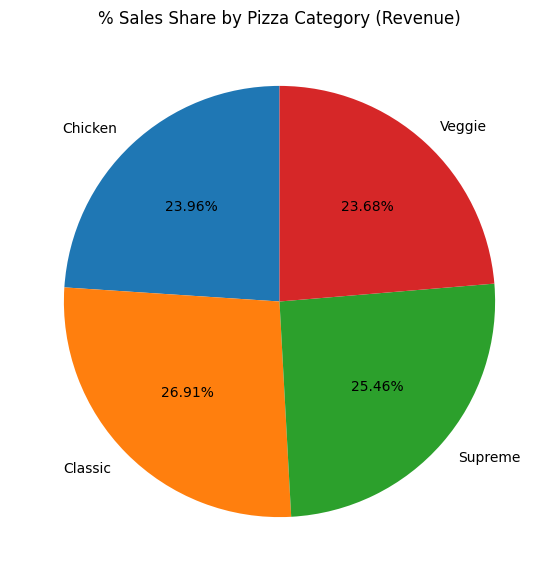

In [115]:
plt.figure(figsize=(7,7))
plt.pie(category_percent, labels=category_percent.index,
        autopct='%1.2f%%', startangle=90)
plt.title("% Sales Share by Pizza Category (Revenue)")
plt.show()


In [109]:
# Count orders per category
category_orders = df.groupby('pizza_category')['order_id'].nunique()

# Calculate % share
category_percent_orders = (category_orders / category_orders.sum()) * 100

# Format to 2 decimals
category_percent_orders = category_percent_orders.round(2)

category_percent_orders


,order_id
pizza_category,
Chicken,22.81
Classic,29.02
Supreme,24.28
Veggie,23.89


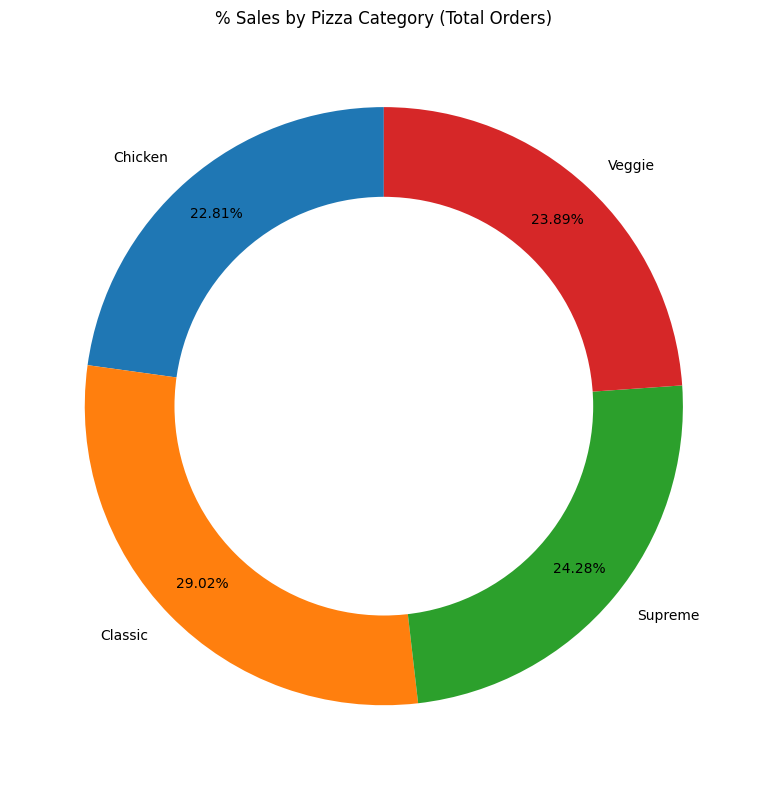

In [112]:
# Group by pizza category and count unique orders
category_orders = df.groupby('pizza_category')['order_id'].nunique()

# Calculate % share
category_percent = (category_orders / category_orders.sum()) * 100

# Donut Chart
plt.figure(figsize=(8,8))
wedges, texts, autotexts = plt.pie(
    category_percent,
    labels=category_percent.index,
    autopct='%1.2f%%',
    startangle=90,
    pctdistance=0.85
)

# Draw circle for donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("% Sales by Pizza Category (Total Orders)")
plt.tight_layout()
plt.show()


##%sales by pizza category and Pizza Size ---by Total Orders

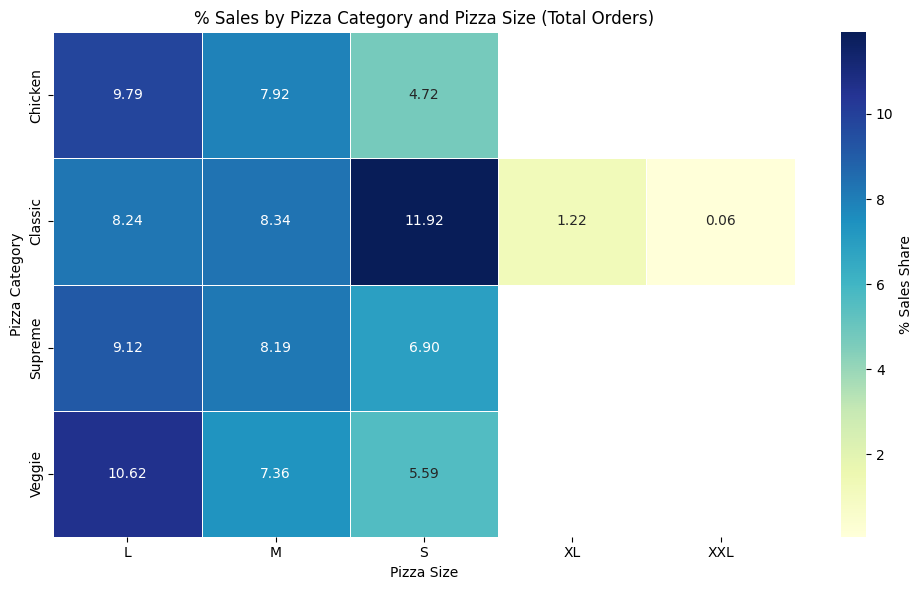

In [116]:
# 1. Create pivot table of total orders
pivot_orders = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='order_id',
    aggfunc='nunique'
)

# 2. Convert to % share by dividing each value by the total
pivot_percent = (pivot_orders / pivot_orders.sum().sum()) * 100

# 3. Format to 2 decimals
pivot_percent = pivot_percent.round(2)

# 4. Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_percent,
    annot=True,           # show values
    fmt=".2f",            # 2 decimal places
    cmap="YlGnBu",        # color palette
    linewidths=0.5,
    cbar_kws={'label': '% Sales Share'}
)

plt.title("% Sales by Pizza Category and Pizza Size (Total Orders)")
plt.xlabel("Pizza Size")
plt.ylabel("Pizza Category")

plt.tight_layout()
plt.show()


##%sales by pizza category and Pizza Size ---by Total Revenue

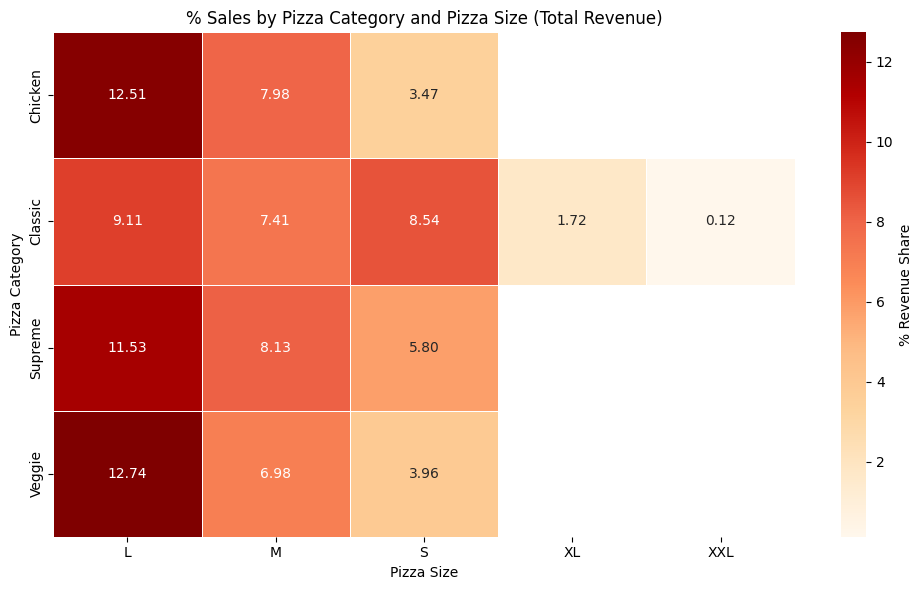

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create pivot table of total revenue
pivot_revenue = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='total_price',
    aggfunc='sum'
)

# 2. Convert to % share
pivot_percent_rev = (pivot_revenue / pivot_revenue.sum().sum()) * 100

# 3. Round to 2 decimals
pivot_percent_rev = pivot_percent_rev.round(2)

# 4. Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_percent_rev,
    annot=True,
    fmt=".2f",
    cmap="OrRd",          # warm color for revenue
    linewidths=0.5,
    cbar_kws={'label': '% Revenue Share'}
)

plt.title("% Sales by Pizza Category and Pizza Size (Total Revenue)")
plt.xlabel("Pizza Size")
plt.ylabel("Pizza Category")

plt.tight_layout()
plt.show()


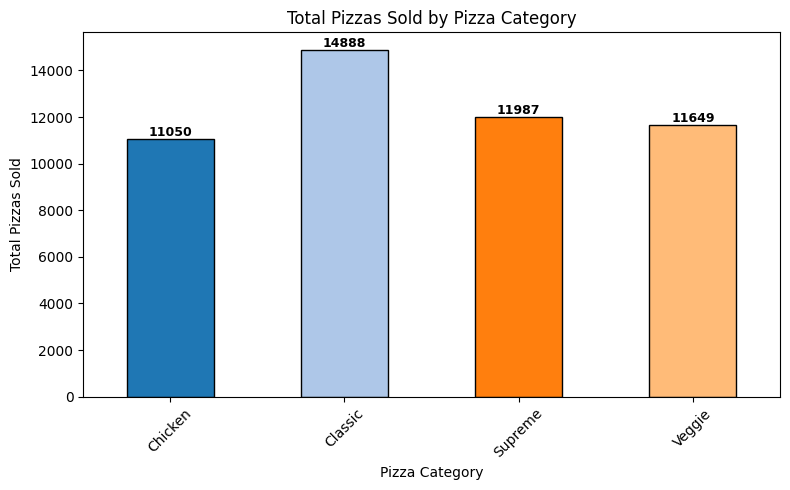

In [120]:
# Calculate total pizzas sold by category (using quantity column)
pizzas_by_category = df.groupby('pizza_category')['quantity'].sum()

# Generate colors from tab20 colormap
colors = list(plt.get_cmap('tab20').colors)

# Trim color list to match number of categories
colors = colors[:len(pizzas_by_category)]

# Plot bar chart
ax = pizzas_by_category.plot(
    kind='bar',
    figsize=(8,5),
    color=colors,
    edgecolor='black'
)

# Title and labels
plt.title("Total Pizzas Sold by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

# Add values above bars
for i, val in enumerate(pizzas_by_category):
    plt.text(i, val + 5, str(val), ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [123]:
# 1. Build one summary table for each pizza
pizza_summary = (
    df.groupby('pizza_name')
      .agg(
          total_quantity=('quantity', 'sum'),
          total_orders=('order_id', 'nunique'),
          total_revenue=('total_price', 'sum')
      )
      .reset_index()
)

# 2. Top 5 by Quantity
top5_by_quantity = (
    pizza_summary
    .sort_values('total_quantity', ascending=False)
    .head(5)
)

# 3. Top 5 by Total Orders
top5_by_orders = (
    pizza_summary
    .sort_values('total_orders', ascending=False)
    .head(5)
)

# 4. Top 5 by Total Revenue
top5_by_revenue = (
    pizza_summary
    .sort_values('total_revenue', ascending=False)
    .head(5)
)

print("Top 5 Pizzas by Quantity:")
print(top5_by_quantity, "\n")

print("Top 5 Pizzas by Total Orders:")
print(top5_by_orders, "\n")

print("Top 5 Pizzas by Total Revenue:")
print(top5_by_revenue)


Top 5 Pizzas by Quantity:
                    pizza_name  total_quantity  total_orders  total_revenue
7     The Classic Deluxe Pizza            2453          2329       38180.50
0   The Barbecue Chicken Pizza            2432          2273       42768.00
12          The Hawaiian Pizza            2422          2280       32273.25
20         The Pepperoni Pizza            2418          2278       30161.75
30      The Thai Chicken Pizza            2371          2225       43434.25 

Top 5 Pizzas by Total Orders:
                    pizza_name  total_quantity  total_orders  total_revenue
7     The Classic Deluxe Pizza            2453          2329       38180.50
12          The Hawaiian Pizza            2422          2280       32273.25
20         The Pepperoni Pizza            2418          2278       30161.75
0   The Barbecue Chicken Pizza            2432          2273       42768.00
30      The Thai Chicken Pizza            2371          2225       43434.25 

Top 5 Pizzas by Total Revenu

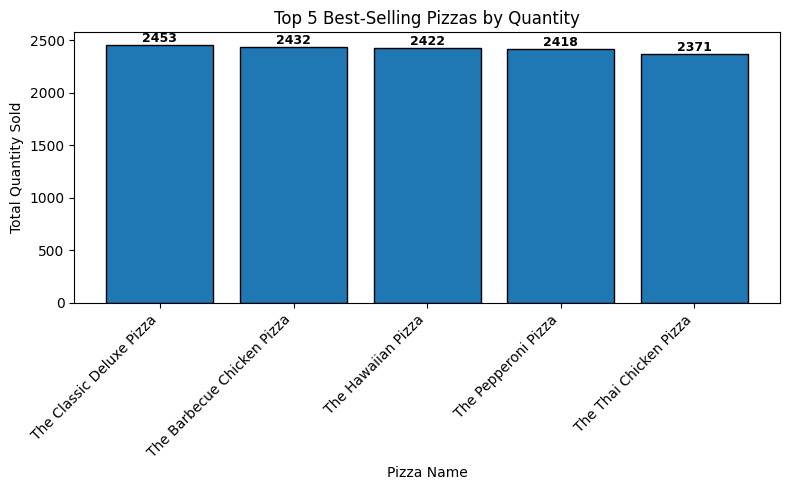

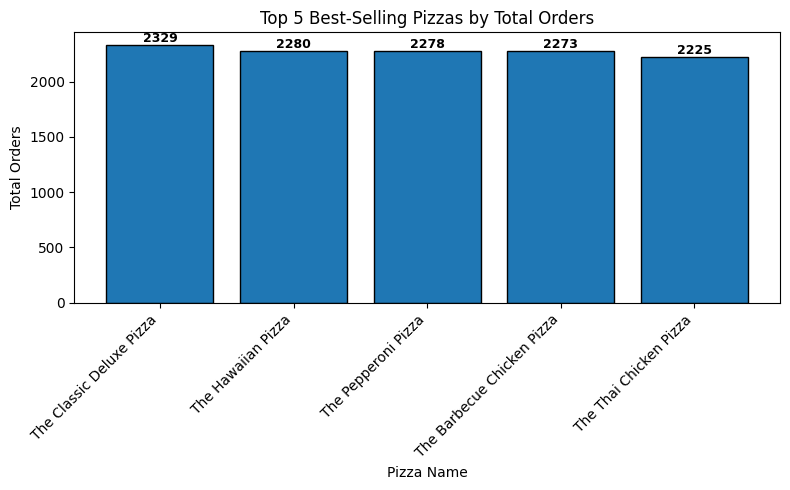

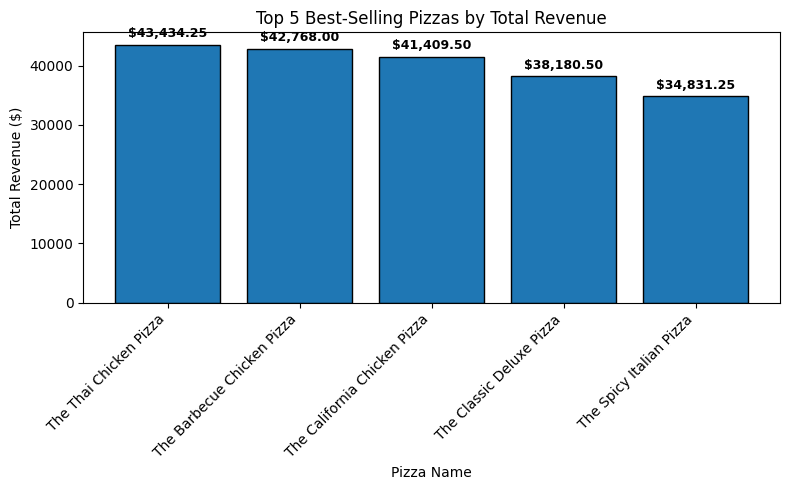

In [124]:
import matplotlib.pyplot as plt

# 1️⃣ Summary table for each pizza
pizza_summary = (
    df.groupby('pizza_name')
      .agg(
          total_quantity=('quantity', 'sum'),
          total_orders=('order_id', 'nunique'),
          total_revenue=('total_price', 'sum')
      )
      .reset_index()
)

# 2️⃣ Top 5 by Quantity
top5_by_quantity = (
    pizza_summary
    .sort_values('total_quantity', ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))
plt.bar(top5_by_quantity['pizza_name'],
        top5_by_quantity['total_quantity'],
        edgecolor='black')

plt.title("Top 5 Best-Selling Pizzas by Quantity")
plt.xlabel("Pizza Name")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(top5_by_quantity['total_quantity']):
    plt.text(i, val + 2, str(val), ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# 3️⃣ Top 5 by Total Orders
top5_by_orders = (
    pizza_summary
    .sort_values('total_orders', ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))
plt.bar(top5_by_orders['pizza_name'],
        top5_by_orders['total_orders'],
        edgecolor='black')

plt.title("Top 5 Best-Selling Pizzas by Total Orders")
plt.xlabel("Pizza Name")
plt.ylabel("Total Orders")
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(top5_by_orders['total_orders']):
    plt.text(i, val + 1, str(val), ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# 4️⃣ Top 5 by Total Revenue
top5_by_revenue = (
    pizza_summary
    .sort_values('total_revenue', ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))
plt.bar(top5_by_revenue['pizza_name'],
        top5_by_revenue['total_revenue'],
        edgecolor='black')

plt.title("Top 5 Best-Selling Pizzas by Total Revenue")
plt.xlabel("Pizza Name")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(top5_by_revenue['total_revenue']):
    plt.text(i, val + (val * 0.02),
             f"${val:,.2f}",
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
